In [1]:
from google.colab import files
uploaded = files.upload()

Saving uber_request_cleaned_data.csv to uber_request_cleaned_data.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('uber_request_cleaned_data.csv')

In [3]:
df.head()

,request_id,pickup_point,driver_id,status,request_timestamp,drop_timestamp,request_hour,request_date,time_slot
0,619,Airport,1.0,Trip Completed,11-07-2016 11:51,11-07-2016 13:00,11,11-07-2016,Morning
1,867,Airport,1.0,Trip Completed,11-07-2016 17:57,11-07-2016 18:47,17,11-07-2016,Evening
2,1807,City,1.0,Trip Completed,12-07-2016 09:17,12-07-2016 09:58,9,12-07-2016,Morning
3,2532,Airport,1.0,Trip Completed,12-07-2016 21:08,12-07-2016 22:03,21,12-07-2016,Evening
4,3112,City,1.0,Trip Completed,13-07-2016 08:33,13-07-2016 09:25,8,13-07-2016,Morning


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   request_id         6745 non-null   int64  
 1   pickup_point       6745 non-null   object 
 2   driver_id          4095 non-null   float64
 3   status             6745 non-null   object 
 4   request_timestamp  6745 non-null   object 
 5   drop_timestamp     2831 non-null   object 
 6   request_hour       6745 non-null   int64  
 7   request_date       6745 non-null   object 
 8   time_slot          6745 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 474.4+ KB


In [5]:
df.isnull().sum()

,0
request_id,0
pickup_point,0
driver_id,2650
status,0
request_timestamp,0
drop_timestamp,3914
request_hour,0
request_date,0
time_slot,0


In [6]:
df.describe()

,request_id,driver_id,request_hour
count,6745.000000,4095.000000,6745.000000
mean,3384.644922,149.501343,12.956709
std,1955.099667,86.051994,6.504052
min,1.000000,1.000000,0.000000
25%,1691.000000,75.000000,7.000000
50%,3387.000000,149.000000,13.000000
75%,5080.000000,224.000000,19.000000
max,6766.000000,300.000000,23.000000


In [7]:
df['request_timestamp'] = pd.to_datetime(
    df['request_timestamp'],
    format='%d-%m-%Y %H:%M'
)

df['drop_timestamp'] = pd.to_datetime(
    df['drop_timestamp'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

In [8]:
df['hour'] = df['request_timestamp'].dt.hour

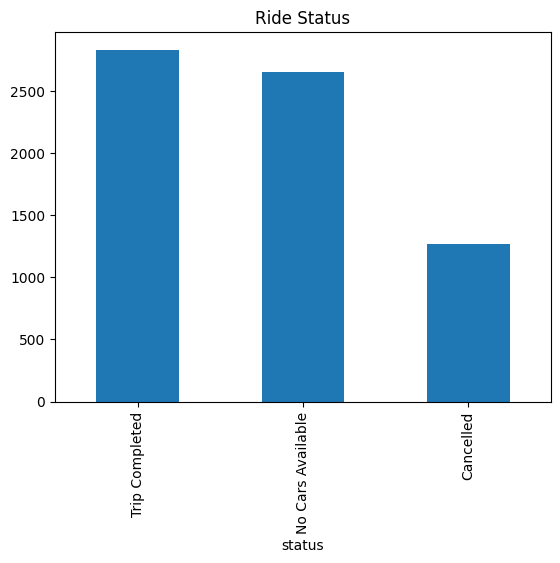

In [9]:
df['status'].value_counts().plot(kind='bar')
plt.title('Ride Status')
plt.show()

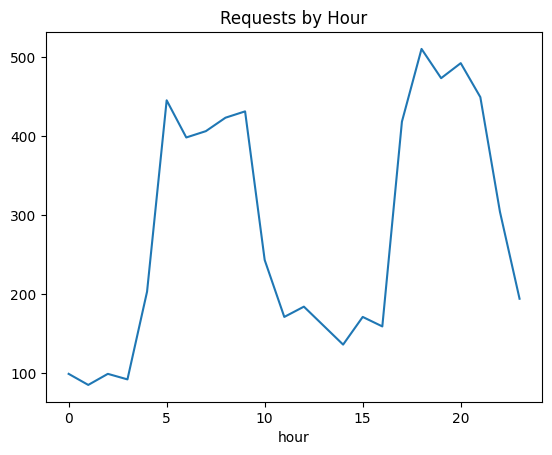

In [10]:
df['hour'].value_counts().sort_index().plot(kind='line')
plt.title('Requests by Hour')
plt.show()

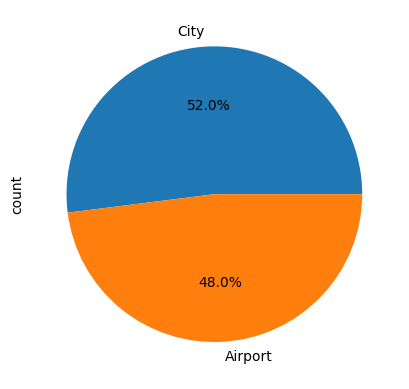

In [11]:
df['pickup_point'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

In [12]:
pivot = pd.pivot_table(
    df,
    values='request_id',
    index='hour',
    columns='status',
    aggfunc='count'
)

print(pivot)

status  Cancelled  No Cars Available  Trip Completed
hour                                                
0               3                 56              40
1               4                 56              25
2               5                 57              37
3               2                 56              34
4              51                 74              78
5             176                 84             185
6             145                 86             167
7             169                 63             174
8             178                 90             155
9             175                 83             173
10             62                 65             116
11             15                 41             115
12             19                 44             121
13             18                 53              89
14             11                 37              88
15             21                 48             102
16             22                 46          